In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

if os.environ.get("OPENAI_API_KEY"):
    print("bro it is working")


from langchain.chat_models import init_chat_model

llm_model = init_chat_model(model="gpt-5-nano")

bro it is working


In [2]:
from pydantic import BaseModel, Field

class strcutredgraph_schema(BaseModel):
    topic: str = Field(description="The topic of the graph")
    post: str = Field(description="The linkedIn post content")
    curated_post: str = Field(description="The curated LinkedIn post content")

In [6]:
from requests.models import Response
def create_post(schema:strcutredgraph_schema):

    topic = schema.topic

    Llm_Response = llm_model.invoke(f" Write a small linkedIn post about {topic}").content

    schema.post = Llm_Response

    return schema



def curate_post(schema:strcutredgraph_schema):

    post = schema.post

    Llm_Resposne = llm_model.invoke(f"Curate the following linkedIn post {post}").content

    schema.curated_post = Llm_Resposne

    return schema


In [24]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(strcutredgraph_schema)

graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)


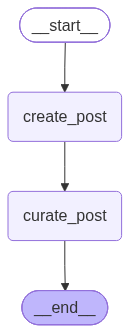

In [9]:
from IPython.display import Image, display

graph = graph.compile()

Image(graph.get_graph().draw_mermaid_png())

In [12]:
graph.invoke({
    "topic" : "LLM importance",
    "post" : "",
    "curated_post" : ""
    })

{'topic': 'LLM importance',
 'post': 'LLMs aren’t just “fancy chatbots” — they’re engines for amplified thinking. They help translate data into insights, draft content, generate code templates, and support multilingual customer conversations, letting teams move faster at scale. The real value comes when humans and AI collaborate: define clear use cases, build guardrails for privacy and bias, and measure impact with concrete metrics. In our org, LLMs cut response times, boost consistency, and free experts to tackle higher‑value work. Start with a small pilot, document outcomes, and share learnings across teams. The future is collaborative AI—responsible adoption will drive the fastest ROI. What use case is delivering the most value in your field? #AI #LLM #FutureOfWork #ResponsibleAI #Productivity',
 'curated_post': 'Here’s a polished version you can paste directly to LinkedIn, plus a couple of quick alternatives you can adapt.\n\n1) Polished post (ready to paste)\nLLMs aren’t just “fan

SAME IN LANGCHIAN

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough


topic_template = ChatPromptTemplate.from_messages([
    ("system", "you are a linnkedIn post generator"),
    ("human", "write a small InkedIn post about {topic}")
])

llm_model = init_chat_model(model="gpt-5-mini")

str_parser = StrOutputParser()

chain_topic = topic_template | llm_model | str_parser

chain_topic_runnable = RunnablePassthrough.assign(post=chain_topic)

#chain_topic_runnable.invoke({"topic" : "LLM"})

{'topic': 'LLM',
 'post': 'LLMs are reshaping how we work — accelerating research, automating routine tasks, and enhancing customer experiences. They can boost productivity dramatically, but require guardrails: prompt design, data privacy, and human review to avoid mistakes and bias. The best results come from pairing LLMs with domain expertise and iterative evaluation. How is your team using LLMs today? #AI #LLM'}

In [22]:
curatePost_template = ChatPromptTemplate.from_messages([
   ("human", "write a small curated InkedIn post about {post}")
])

llm_model = init_chat_model(model="gpt-5-mini")

str_parser = StrOutputParser()

chain_curatePost = curatePost_template | llm_model | str_parser

chain_curate_runnable = RunnablePassthrough.assign(curated_post = chain_curatePost)

In [23]:
final_chian = chain_topic_runnable | chain_curate_runnable

final_chian.invoke({"topic":"LLM"})

{'topic': 'LLM',
 'post': 'Large language models (LLMs) are transforming how we work—automating routine writing, accelerating research, and surfacing new product ideas. But along with speed and scale come risks: hallucinations, bias, and data-privacy concerns that demand clear guardrails. The teams that win will pair domain expertise with thoughtful prompt design, rigorous evaluation, and responsible deployment. How is your organization using LLMs today—or what’s the biggest challenge you’re facing?',
 'curated_post': 'Large language models are changing how we work—automating routine writing, accelerating research, and surfacing novel product ideas. But speed and scale bring real risks: hallucinations, bias, and data-privacy gaps that demand clear guardrails. The teams that win will pair domain expertise with thoughtful prompt design, rigorous evaluation, and responsible deployment. How is your organization using LLMs today—or what’s the biggest challenge you’re facing?'}